# Bussiness Problem

- Create predictive model, which can be predict whethere daibetic or not

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df= pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.shape

(768, 9)

# EDA

In [7]:
contineous=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']
discret_count=['Pregnancies']
discret_categorical=['Outcome']

In [8]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [9]:
df['Outcome'].unique()

array([1, 0])

In [10]:
df[contineous].describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


In [11]:
df[contineous].corr()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Glucose,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514
BloodPressure,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528
SkinThickness,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970
Insulin,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163
BMI,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242
DiabetesPedigreeFunction,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561
Age,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000


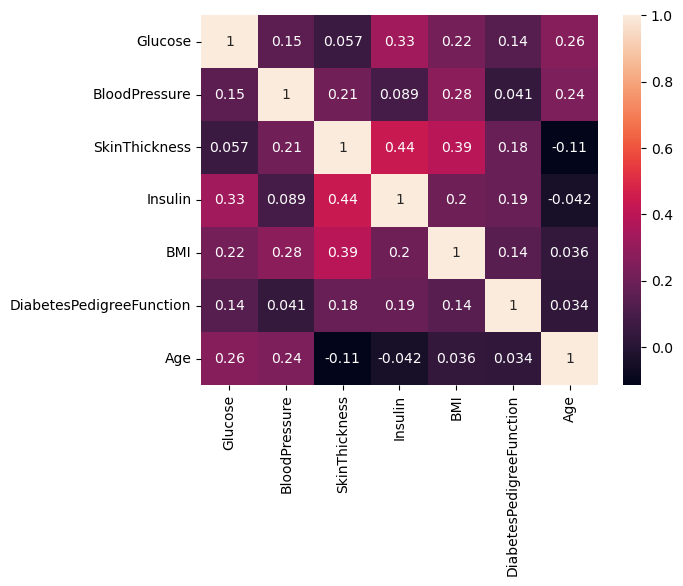

In [12]:
sns.heatmap(df[contineous].corr(),annot=True)
plt.show()

# Data cleaning

In [13]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[contineous].skew()

Glucose                     0.173754
BloodPressure              -1.843608
SkinThickness               0.109372
Insulin                     2.272251
BMI                        -0.428982
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64

In [16]:
df[contineous].head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,148,72,35,0,33.6,0.627,50
1,85,66,29,0,26.6,0.351,31
2,183,64,0,0,23.3,0.672,32
3,89,66,23,94,28.1,0.167,21
4,137,40,35,168,43.1,2.288,33


In [17]:
df['Glucose'].max()

199

In [18]:
df['BloodPressure'].max()

122

In [19]:
df['SkinThickness'].mean()

np.float64(20.536458333333332)

In [20]:
df['Insulin'].max()

846

In [21]:
df['BMI'].max()

67.1

- ***There is no possibility to Glucose,BP,SkinThickness,Insulin and BMI are equal to Zero(0).***
- ***So to replace the original values in these variables.***

In [22]:
df['Glucose']=df['Glucose'].replace(0,120)

In [23]:
df['Glucose'].min()

44

In [24]:
df['BloodPressure']=df['BloodPressure'].replace(0,69)

In [25]:
df['BloodPressure'].min()

24

In [26]:
df['SkinThickness']=df['SkinThickness'].replace(0,20)

In [27]:
df['SkinThickness'].min()

7

In [28]:
df['Insulin']=df['Insulin'].replace(0,118)

In [29]:
df['Insulin'].min()

14

In [30]:
df['BMI']=df['BMI'].replace(0,79)

In [31]:
df['BMI'].min()

18.2

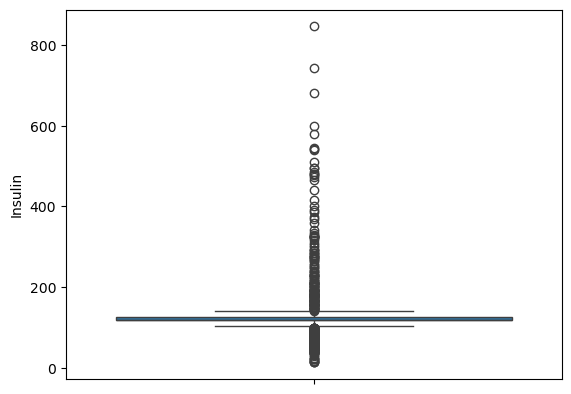

In [32]:
sns.boxplot(df['Insulin'])   #There are some outliers
plt.show()

In [33]:
Q1=df["Insulin"].quantile(0.25)
print("Q1:",Q1)
Q3=df['Insulin'].quantile(0.75)
print("Q3:",Q3)
IQR=Q3-Q1
print("IQR:",IQR)
lower_limit=Q1-(1.5*IQR)
print("lower limit",lower_limit)
upper_limit=Q3+(1.5*IQR)
print("upper limit",upper_limit)

Q1: 118.0
Q3: 127.25
IQR: 9.25
lower limit 104.125
upper limit 141.125


In [34]:
df[(df["Insulin"]<lower_limit)|(df["Insulin"]>upper_limit)]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
748,3,187,70,22,200,36.4,0.408,36,1
751,1,121,78,39,74,39.0,0.261,28,0
753,0,181,88,44,510,43.3,0.222,26,1
760,2,88,58,26,16,28.4,0.766,22,0


In [35]:
df['Insulin']=df['Insulin'].clip(lower=6.625,upper=199.625)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,118.0,33.6,0.627,50,1
1,1,85,66,29,118.0,26.6,0.351,31,0
2,8,183,64,20,118.0,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,118.0,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,20,118.0,30.1,0.349,47,1


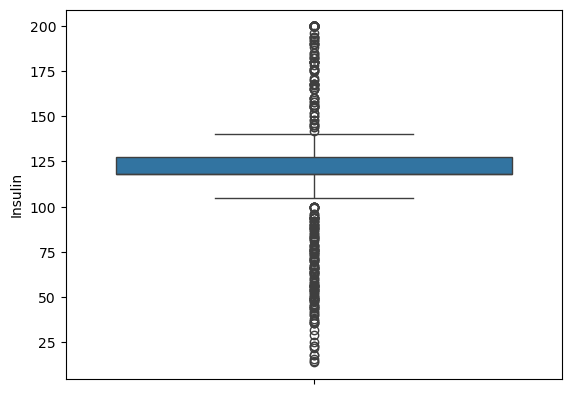

In [36]:
sns.boxplot(df['Insulin'])   #outliers are removed
plt.show()

# Data Wrangling

- No Data wrongling requid

# X & y

In [37]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

# Train Test Split

In [38]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=16)

# Modeling

In [39]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

D:\Ananconda2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [40]:
print("Intercept:",model.intercept_)
print("Coificcent:",model.coef_)

Intercept: [-7.81755996]
Coificcent: [[ 3.30956776e-02  3.57707550e-02 -6.45186626e-03  1.56420884e-02
   6.82667355e-04  4.39867880e-02  7.38489570e-01  2.03414001e-02]]


# prediction

In [44]:
ypread_train=model.predict(X_train)
from sklearn.metrics import accuracy_score
print("Acuracy score:",accuracy_score(y_train,ypread_train))
from sklearn.model_selection import cross_val_score
print("Cross validation score:",cross_val_score(model,X_train,y_train,cv=5,scoring='accuracy').mean())

Acuracy score: 0.750814332247557
Cross validation score: 0.7475809676129548


D:\Ananconda2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Ananconda2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_re

In [42]:
ypred_test=model.predict(X_test)
print("Acuuracy Score for test data:",accuracy_score(y_test,ypred_test))
print("Cross validaton score:",cross_val_score(model,X_test,y_test,cv=5,scoring='accuracy').mean())

Acuuracy Score for test data: 0.8181818181818182
Cross validaton score: 0.7989247311827957


D:\Ananconda2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\Ananconda2\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_re

# Confusion Matrix

In [83]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,ypred_test)
cm

array([[97,  5],
       [23, 29]])

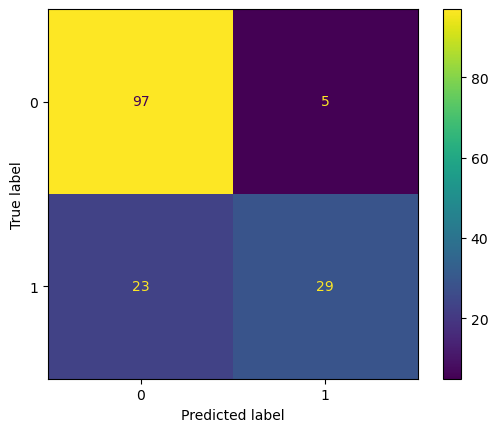

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm,display_labels=[0,1]).plot()
plt.show()

# classification report

In [87]:
from sklearn.metrics import classification_report
print(classification_report(y_test,ypred_test))

              precision    recall  f1-score   support

           0       0.81      0.95      0.87       102
           1       0.85      0.56      0.67        52

    accuracy                           0.82       154
   macro avg       0.83      0.75      0.77       154
weighted avg       0.82      0.82      0.81       154



# Roc curve

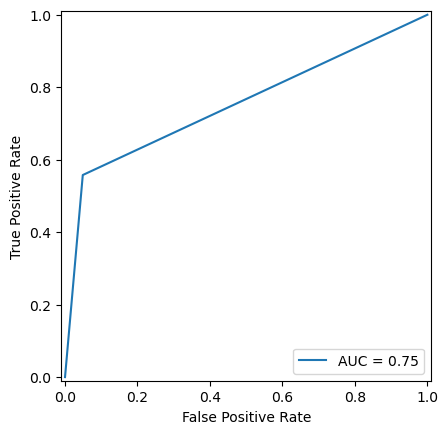

In [90]:
from sklearn.metrics import roc_curve,auc,RocCurveDisplay
fpr,tpr,thresholds=roc_curve(y_test,ypred_test)
roc_auc=auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

# auc score

In [92]:
from sklearn.metrics import roc_auc_score
auc_score=roc_auc_score(y_test,ypred_test)
auc_score

np.float64(0.7543363499245851)